In [34]:
import platform
import torch

if platform.system() == "Darwin":
    device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
else:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

mps


In [35]:
import torch
from torchvision import datasets, transforms
from pathlib import Path
from torch.utils.data import DataLoader

# --- Konfiguration (eine Quelle der Wahrheit) ---
DATA_DIR      = Path("../data/split")

# Daten
IMG_SIZE      = 128      # 64, 128 oder 300 — dein Experiment
BATCH_SIZE    = 32
NUM_WORKERS   = 0

# Modell
NUM_CLASSES   = 10
DROPOUT       = 0.2

# Training
LEARNING_RATE = 0.01
NUM_EPOCHS    = 80

# --- Transformationen ---
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

""" # --- Datasets (lesen die Ordner) ---
train_set = datasets.ImageFolder(DATA_DIR / "train", transform=transform)
val_set   = datasets.ImageFolder(DATA_DIR / "val",   transform=transform)
test_set  = datasets.ImageFolder(DATA_DIR / "test",  transform=transform)

# --- DataLoader (liefern die Batches) ---
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader = torch.utils.data.DataLoader(
    val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(
    test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS) """

# --- Augmentation NUR fürs Training (online, zufällig pro Epoche) ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# --- Val/Test: KEINE Augmentation, nur deterministisch ---
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_set = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
val_set   = datasets.ImageFolder(DATA_DIR / "val",   transform=eval_transform)
test_set  = datasets.ImageFolder(DATA_DIR / "test",  transform=eval_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Beleg fürs Verständnis: Augmentation ändert die Anzahl NICHT
print(f"Trainingsbilder: {len(train_set)}  (unverändert — nur mehr Vielfalt pro Epoche)")

Trainingsbilder: 1787  (unverändert — nur mehr Vielfalt pro Epoche)


In [36]:
# Überprüfen, ob alles korrekt geladen wurde
print("Klassen:", train_set.classes)
print("Bilder (train/val/test):", len(train_set), len(val_set), len(test_set))

images, labels = next(iter(train_loader))
print("Batch-Form:", images.shape)
print("Labels:", labels[:8])

Klassen: ['alternative_rock', 'classical', 'country', 'hiphop', 'house', 'indie_rock', 'jazz', 'metal', 'reggae', 'techno']
Bilder (train/val/test): 1787 381 381
Batch-Form: torch.Size([32, 3, 128, 128])
Labels: tensor([1, 4, 5, 6, 5, 7, 0, 2])


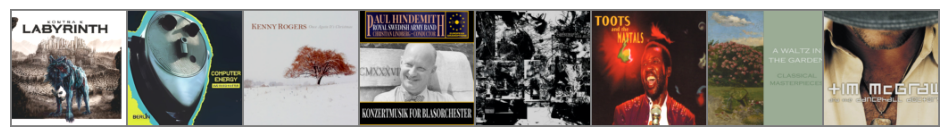

['hiphop', 'jazz', 'country', 'classical', 'techno', 'reggae', 'classical', 'country']


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# --- Bilder anzeigen (Kap. 6.2) ---
def imshow(img):
    img = img / 2 + 0.5                          # Denormalisierung: [-1,1] -> [0,1]
    npimg = img.numpy()                          # Tensor -> NumPy
    plt.imshow(np.transpose(npimg, (1, 2, 0)))   # C×H×W -> H×W×C
    plt.axis("off")

# einen Batch holen
dataiter = iter(train_loader)
images, labels = next(dataiter)

# die ersten 8 als Raster anzeigen
n_show = 8
plt.figure(figsize=(12, 3))
imshow(torchvision.utils.make_grid(images[:n_show]))
plt.show()

# zugehörige Klassennamen (statt Zahlen)
print([train_set.classes[label.item()] for label in labels[:n_show]])

In [38]:
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

# --- Modell-Architektur ---
torch.manual_seed(42)
class CoverCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        
        # Convolutional Layer (Merkmalsextraktion)
        self.conv1 = nn.Conv2d(3,   32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)

        # Pooling Layer
        self.pool          = nn.MaxPool2d(kernel_size=2, stride=2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # Fully Connected Layer (Klassifikation)
        self.fc1     = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- Modell, Loss, Optimizer (alles aus dem Konfig-Block) ---
model     = CoverCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)

# Klassenhäufigkeiten im Trainingsset (alphabetische Label-Reihenfolge)
counts = Counter(train_set.targets)
class_counts = torch.tensor([counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).to(device)
print("Klassengewichte:", class_weights)

loss_fn   = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9) # torch.optim.Adam(model.parameters(), lr=LEARNING_RATE) # torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

Klassengewichte: tensor([1.0096, 1.2240, 1.1455, 1.0830, 0.9307, 0.9659, 0.9455, 0.9259, 1.0211,
        0.8550], device='mps:0')


In [39]:
import torchmetrics

# Metriken (eine fürs Training, eine für die Validierung)
train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)
val_accuracy   = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)

# Verläufe (für die spätere Overfitting-Auswertung)
train_loss_hist, train_acc_hist = {}, {}
val_loss_hist,   val_acc_hist   = {}, {}

best_val_acc = 0.0
BEST_PATH = "../models/run14.pt"

for epoch in range(NUM_EPOCHS):

    # ---------- Training ----------
    model.train()                      # Trainingsmodus -> Dropout AKTIV
    running_loss, num_batches = 0.0, 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        pred = model(images)           # 1. Vorhersage (Logits)
        loss = loss_fn(pred, labels)   # 2. Fehler berechnen
        loss.backward()                # 3. Gradienten berechnen
        optimizer.step()               # 4. Gewichte anpassen
        optimizer.zero_grad()          # 5. Gradienten zurücksetzen

        train_accuracy.update(pred, labels)
        running_loss += loss.item()
        num_batches  += 1

    train_loss_hist[epoch] = running_loss / num_batches
    train_acc_hist[epoch]  = train_accuracy.compute().item()

    # ---------- Validierung ----------
    model.eval()                       # Eval-Modus -> Dropout AUS
    running_val_loss, num_val_batches = 0.0, 0

    with torch.no_grad():              # keine Gradienten -> schneller, spart Speicher
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            pred = model(images)
            loss = loss_fn(pred, labels)

            val_accuracy.update(pred, labels)
            running_val_loss += loss.item()
            num_val_batches  += 1

    val_loss_hist[epoch] = running_val_loss / num_val_batches
    val_acc_hist[epoch]  = val_accuracy.compute().item()

    # bestes Modell sichern, sobald val-Accuracy sich verbessert
    if val_acc_hist[epoch] > best_val_acc:
        best_val_acc = val_acc_hist[epoch]
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> neuer Best-Checkpoint @ Epoche {epoch}: {best_val_acc:.4f}")

    train_accuracy.reset()             # Metriken für nächste Epoche zurücksetzen
    val_accuracy.reset()

    print(f"Epoch {epoch:>2} | "
          f"train loss {train_loss_hist[epoch]:.3f}  acc {train_acc_hist[epoch]:.3f} | "
          f"val loss {val_loss_hist[epoch]:.3f}  acc {val_acc_hist[epoch]:.3f}")

  -> neuer Best-Checkpoint @ Epoche 0: 0.1365
Epoch  0 | train loss 2.304  acc 0.101 | val loss 2.298  acc 0.136
  -> neuer Best-Checkpoint @ Epoche 1: 0.1601
Epoch  1 | train loss 2.300  acc 0.127 | val loss 2.290  acc 0.160
Epoch  2 | train loss 2.295  acc 0.142 | val loss 2.283  acc 0.144
Epoch  3 | train loss 2.287  acc 0.151 | val loss 2.260  acc 0.152
Epoch  4 | train loss 2.278  acc 0.151 | val loss 2.253  acc 0.157
  -> neuer Best-Checkpoint @ Epoche 5: 0.1732
Epoch  5 | train loss 2.266  acc 0.157 | val loss 2.232  acc 0.173
Epoch  6 | train loss 2.265  acc 0.161 | val loss 2.220  acc 0.168
  -> neuer Best-Checkpoint @ Epoche 7: 0.1811
Epoch  7 | train loss 2.245  acc 0.170 | val loss 2.202  acc 0.181
Epoch  8 | train loss 2.232  acc 0.193 | val loss 2.234  acc 0.150
  -> neuer Best-Checkpoint @ Epoche 9: 0.1969
Epoch  9 | train loss 2.239  acc 0.167 | val loss 2.202  acc 0.197
Epoch 10 | train loss 2.232  acc 0.194 | val loss 2.199  acc 0.173
Epoch 11 | train loss 2.206  acc 

In [40]:
import altair as alt
import pandas as pd

def hist_to_df(train_hist, val_hist, value_name):
    train_df = pd.DataFrame.from_dict(train_hist, orient="index").reset_index()
    train_df["Type"] = "train"
    val_df = pd.DataFrame.from_dict(val_hist, orient="index").reset_index()
    val_df["Type"] = "validation"
    df = pd.concat([train_df, val_df])
    df.columns = ["Epoch", value_name, "Type"]
    return df

loss_df = hist_to_df(train_loss_hist, val_loss_hist, "Loss")
acc_df  = hist_to_df(train_acc_hist,  val_acc_hist,  "Accuracy")

loss_chart = alt.Chart(loss_df).mark_line().encode(
    x="Epoch", y="Loss", color="Type").properties(title="Loss pro Epoche", width=350)
acc_chart = alt.Chart(acc_df).mark_line().encode(
    x="Epoch", y="Accuracy", color="Type").properties(title="Accuracy pro Epoche", width=350)

loss_chart | acc_chart      # nebeneinander (| = horizontal, & wäre untereinander)

alt.HConcatChart(...)

In [41]:
import pandas as pd
import json
import torch
from datetime import datetime
from pathlib import Path

# --- HIER pro Lauf anpassen: was hast du verändert? ---
RUN_NOTE = "Dropout von 0.5 auf 0.2 reduziert"

LOG_FILE    = Path("../experiments.csv")
MODELS_DIR  = Path("../models")
RESULTS_DIR = Path("../results")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

last_epoch = max(val_acc_hist)
best_epoch = max(val_acc_hist, key=val_acc_hist.get)

# run_id automatisch hochzählen
if LOG_FILE.exists():
    log = pd.read_csv(LOG_FILE)
    run_id = int(log["run_id"].max()) + 1
else:
    log = pd.DataFrame()
    run_id = 1

# 1) Zeile fürs CSV-Log
row = {
    "run_id":           run_id,
    "timestamp":        datetime.now().strftime("%Y-%m-%d %H:%M"),
    "note":             RUN_NOTE,
    "img_size":         IMG_SIZE,
    "batch_size":       BATCH_SIZE,
    "optimizer":        type(optimizer).__name__,
    "lr":               optimizer.param_groups[0]["lr"],
    "momentum":         optimizer.param_groups[0].get("momentum", ""),
    "weight_decay":     optimizer.param_groups[0].get("weight_decay", ""),
    "dropout":          DROPOUT,
    "epochs":           last_epoch + 1,
    "final_train_loss": round(train_loss_hist[last_epoch], 4),
    "final_val_loss":   round(val_loss_hist[last_epoch], 4),
    "final_train_acc":  round(train_acc_hist[last_epoch], 4),
    "final_val_acc":    round(val_acc_hist[last_epoch], 4),
    "best_val_acc":     round(val_acc_hist[best_epoch], 4),
    "best_epoch":       best_epoch,
}
log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
log.to_csv(LOG_FILE, index=False)

# 2) Modellgewichte sichern
torch.save(model.state_dict(), MODELS_DIR / f"run_{run_id}.pt")

# 3) vollständige Verläufe sichern (zum späteren Re-Plotten)
history = {
    "train_loss": list(train_loss_hist.values()),
    "val_loss":   list(val_loss_hist.values()),
    "train_acc":  list(train_acc_hist.values()),
    "val_acc":    list(val_acc_hist.values()),
}
with open(RESULTS_DIR / f"run_{run_id}.json", "w") as f:
    json.dump(history, f)

print(f"Lauf #{run_id}: CSV + models/run_{run_id}.pt + results/run_{run_id}.json")
log

Lauf #14: CSV + models/run_14.pt + results/run_14.json


,run_id,timestamp,note,img_size,batch_size,optimizer,lr,momentum,dropout,epochs,final_train_loss,final_val_loss,final_train_acc,final_val_acc,best_val_acc,best_epoch,weight_decay
0,1,2026-06-02 11:28,Erster run mit Baseline-Architektur,128,32,SGD,0.001,0.9,0.5,30,2.2503,2.2240,0.1645,0.2126,0.2126,29,NaN
1,2,2026-06-02 11:31,Ich habe die Lernrate von 0.001 auf 0.01 erhöht,128,32,SGD,0.010,0.9,0.5,30,1.9398,2.1268,0.2966,0.2520,0.2520,29,NaN
2,3,2026-06-02 11:42,Epochs von 30 auf 80 erhöht,128,32,SGD,0.010,0.9,0.5,80,0.4555,3.9653,0.8489,0.2520,0.2782,51,NaN
3,4,2026-06-02 12:02,Epochs von 50 auf 50 angepasst,128,32,SGD,0.010,0.9,0.5,50,1.3277,2.4144,0.5400,0.2835,0.2835,49,NaN
4,5,2026-06-02 12:08,Learning rate von 0.01 auf 0.001 und Adam-Opti...,128,32,Adam,0.001,NaN,0.5,50,0.4164,4.8040,0.8500,0.2441,0.2730,15,NaN
5,6,2026-06-02 13:00,Weight Decay 1e-4 als Regularisierung hinzugefügt,128,32,SGD,0.001,0.9,0.5,50,2.1998,2.1800,0.1998,0.2047,0.2100,30,0.0001
6,7,2026-06-02 13:12,"learning rate wieder von 0.001 auf 0.01, Adam-...",128,32,SGD,0.010,0.9,0.5,50,1.2846,2.5935,0.5607,0.2283,0.2598,47,0.0001
7,8,2026-06-02 13:20,"IMG_SIZE von 128 auf 64 reduziert, um zu sehen...",64,32,SGD,0.010,0.9,0.5,50,0.8575,2.8378,0.7096,0.2546,0.2598,31,0.0001
8,9,2026-06-02 13:27,weight_decay=1e-4 nochmal wieder raus nehmen,64,32,SGD,0.010,0.9,0.5,50,0.6984,3.1054,0.7700,0.2073,0.2467,38,0.0000
9,10,2026-06-04 14:52,"IMG_SIZE to 128, NUM_EPOCHS to 80 & ich habe A...",128,32,SGD,0.010,0.9,0.5,80,0.8864,2.9695,0.6950,0.2651,0.2808,59,0.0000
